GRADIENT BOOSTING NO PCA

Jack Silkaitis

In [ ]:
# Imports
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [74]:
# Import data
df = pd.read_csv('./CleanPreprocessedExoplanet2.csv')
df.head(3)
df.shape

(1788, 51)

In [ ]:
# Check cols
df.columns

Index(['Unnamed: 0', 'release_month', 'sy_snum', 'sy_pnum', 'cb_flag',
       'ttv_flag', 'pl_nnotes', 'elon', 'elat', 'glon', 'glat', 'dec', 'ra',
       'st_nspec', 'pl_nespec', 'pl_ntranspec', 'pl_ndispec', 'release_year',
       'st_nphot', 'st_nrvc', 'pl_controv_flag', 'disc_year', 'sy_tmag',
       'sy_kmag', 'sy_jmag', 'sy_hmag', 'sy_vmag', 'sy_pm', 'sy_pmdec',
       'sy_pmra', 'pl_orbper', 'sy_gaiamag', 'st_rad', 'sy_bmag', 'sy_dist',
       'st_teff', 'sy_w2mag', 'sy_w1mag', 'sy_w3mag', 'sy_w4mag', 'sy_plx',
       'st_logg', 'st_mass',
       'soltype_Kepler Project Candidate (q1_q17_dr25_koi)',
       'soltype_Published Confirmed', 'pl_tsystemref_BJD',
       'pl_tsystemref_BJD-TDB', 'pl_tsystemref_BJD-UTC', 'pl_tsystemref_HJD',
       'pl_tsystemref_JD', 'log radius'],
      dtype='object')

In [76]:
# Split and prepare data
(df_train,df_test) = train_test_split(df,train_size=0.8,
                                      test_size=0.2,
                                      random_state=0)

In [ ]:
# Preprocess data
X_train = df_train.drop(['log radius','Unnamed: 0'],axis=1)
y_train = df_train['log radius']
X_test = df_test.drop(['log radius','Unnamed: 0'],axis=1)
y_test = df_test['log radius']

In [ ]:
# Standardize
stnd = StandardScaler().set_output(transform='pandas')

X_number = X_train.select_dtypes(include='number')
X_categorical = X_train.select_dtypes(exclude='number')
X_number = stnd.fit_transform(X_number)
X_train = pd.concat([X_number, X_categorical], axis=1)

X_number = X_test.select_dtypes(include='number')
X_categorical = X_test.select_dtypes(exclude='number')
X_number = stnd.transform(X_number)
X_test = pd.concat([X_number, X_categorical], axis=1)

In [79]:
# Baseline before applying PCA, arbitrary max_depth
tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X_train,y_train)
tree.score(X_test, y_test)

0.13648169148643174

In [ ]:
# First grid search CV
B = np.arange(1,301,100)
C = np.arange(1,10,3)
D = np.arange(0.01,1,0.33)
grid = {'n_estimators':B, 'max_depth':C, 'learning_rate':D}

gbt = GradientBoostingRegressor()
gbtCV = GridSearchCV(gbt,param_grid=grid,return_train_score=True,n_jobs=-1, verbose=2)
gbtCV.fit(X_train,y_train)

print('best params =',gbtCV.best_params_, '  valid acc =',gbtCV.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
best params = {'learning_rate': np.float64(0.34), 'max_depth': np.int64(1), 'n_estimators': np.int64(201)}   valid acc = 0.3992125069006878


In [ ]:
# Second grid search CV
B = np.arange(150,300,50)
C = np.arange(1,4,1)
D = np.arange(.2, .5, .1)
grid = {'n_estimators':B, 'max_depth':C, 'learning_rate':D}

gbt = GradientBoostingRegressor()
gbtCV = GridSearchCV(gbt,param_grid=grid,return_train_score=True,n_jobs=-1, verbose=2)
gbtCV.fit(X_train,y_train)

print('best params =',gbtCV.best_params_, '  valid acc =',gbtCV.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
best params = {'learning_rate': np.float64(0.2), 'max_depth': np.int64(2), 'n_estimators': np.int64(150)}   valid acc = 0.4047439725709804


In [ ]:
# Keys
gbtCV.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_learning_rate', 'param_max_depth', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [ ]:
# Param pulling out
R2 = gbtCV.cv_results_['mean_train_score']
lam = gbtCV.cv_results_['param_learning_rate']
N = gbtCV.cv_results_['param_n_estimators']
d = gbtCV.cv_results_['param_max_depth']

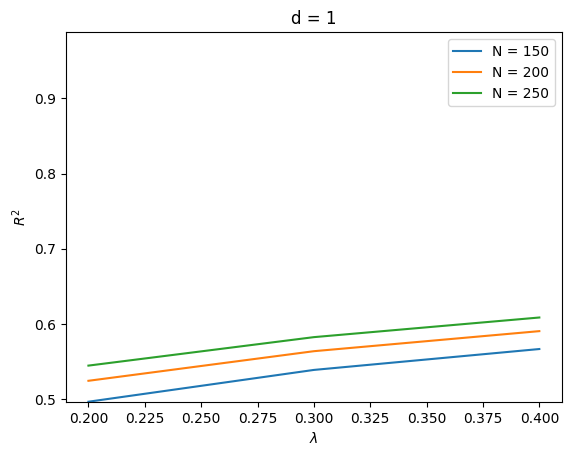

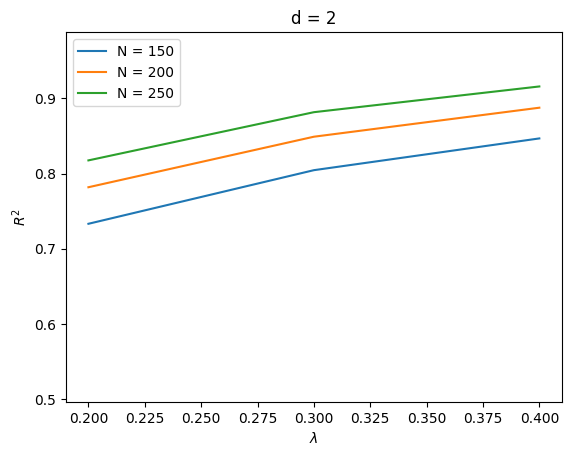

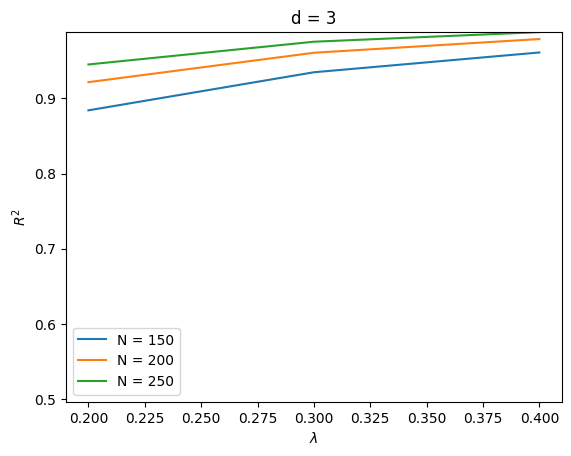

In [ ]:
# Graphing variation of R^2 from changing hyperparams
for d_val in C:
    plt.figure()
    for N_val in B:
        mask = (N == N_val) & (d_val == d)
        plt.plot(lam[mask], R2[mask])
    plt.title(f"d = {d_val}")
    plt.legend([f"N = {N_val}" for N_val in B])
    plt.xlabel(r'$\lambda$')
    plt.ylabel(r'$R^2$')
    plt.ylim([min(R2), max(R2)])
    plt.show()

In [ ]:
# Third CV
B = np.arange(150,225,25)
C = np.arange(.1,.3,.05)
grid = {'n_estimators':B, 'learning_rate':C}

gbt = GradientBoostingRegressor(max_depth=2)
gbtCV = GridSearchCV(gbt,param_grid=grid,return_train_score=True,n_jobs=-1, verbose=2)
gbtCV.fit(X_train,y_train)

print('best params =',gbtCV.best_params_, '  valid acc =',gbtCV.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
best params = {'learning_rate': np.float64(0.15000000000000002), 'n_estimators': np.int64(175)}   valid acc = 0.40737707982870786


In [ ]:
# R2
print('Test R2',gbtCV.score(X_test,y_test))
print('Train R2',gbtCV.score(X_train,y_train))

Test R2 0.48326548443887873
Train R2 0.6748532310559061


In [ ]:
# Training MSE
y_pred = gbtCV.predict(X_train)
mean_squared_error(y_pred, y_train)

0.02511634084042078

In [ ]:
# Test MSE
y_pred = gbtCV.predict(X_test)
mean_squared_error(y_pred, y_test)

0.037007888949681385

In [ ]:
# Mean rel err
np.mean(np.abs(10**(y_pred) - 10**y_test) / 10**y_test)

np.float64(0.33078930560227116)

In [ ]:
# Max rel err
max(np.abs(10**(y_pred) - 10**y_test) / 10**y_test)

1.4262182094671414

In [ ]:
# DF of rel error
df = pd.DataFrame()
df['pred'] = y_pred
df['actual'] = y_test
df['relErr'] = np.abs(10**(y_pred) - 10**y_test) / 10**y_test

In [ ]:
# Max err loc
df.idxmax()

pred      105
actual     14
relErr    177
dtype: int64

In [ ]:
# Max err stats
df.loc[177]

pred      0.823302
actual    0.474216
relErr    1.214201
Name: 177, dtype: float64

In [ ]:
# Min err loc
df.idxmin()

pred      285
actual     52
relErr    260
dtype: int64

In [ ]:
# Min err stats
df.loc[260]

pred      0.539641
actual    0.289589
relErr    0.003390
Name: 260, dtype: float64

In [ ]:
# Min rel err
min(np.abs(10**(y_pred) - 10**y_test) / 10**y_test)

0.00021474351045796308

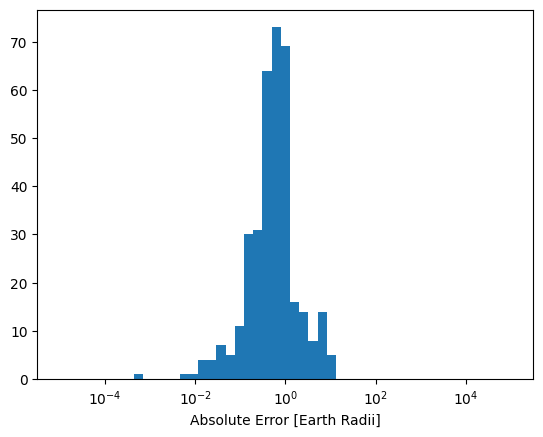

In [ ]:
# Err plot 1
plt.figure()
plt.hist((np.abs(10**y_pred - 10**y_test)), bins=np.logspace(-5,5))
plt.xscale("log")
plt.xlabel("Absolute Error [Earth Radii]")
plt.show()


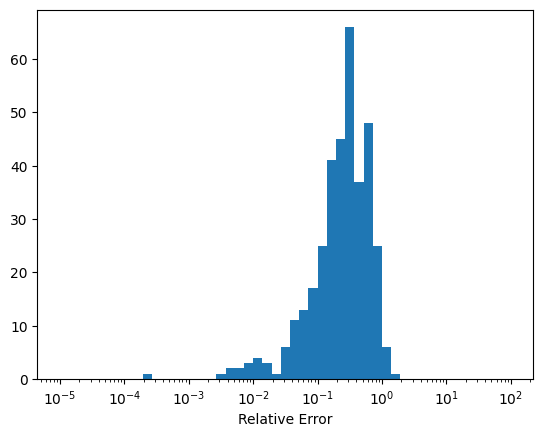

In [ ]:
# Err plot 2
plt.figure()
plt.hist(df['relError'], bins=np.logspace(-5,2))
plt.xscale("log")
plt.xlabel("Relative Error")
plt.show()
